In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    default_assay='RNA',
    nthreads=4,
)

ds

DataStore has 3413 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_cell_cycle_phase', 'RNA_nFeatures', 
            'RNA_nCounts', 'clusters_coarse', 'RNA_percentMito', 'G2M_score', 'RNA_G2M_score', 
            'RNA_percentRibo', 'RNA_S_score', 'RNA_UMAP2', 'RNA_cluster', 'S_score', 
            'RNA_UMAP1', 'clusters'
   RNA assay has 12497 (27998) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'I__hvgs', 
            'nCells', 'highly_variable_genes'

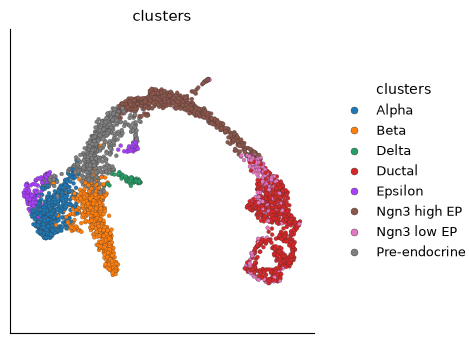

In [3]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
)

In [4]:
ds.show_zarr_tree(depth=1)

/
├── RNA
│   ├── counts (3696, 27998) float32
│   ├── featureData
│   ├── normed__I__hvgs
│   └── summary_stats_I
└── cellData
    ├── G2M_score (3696,) float32
    ├── I (3696,) bool
    ├── RNA_G2M_score (3696,) float64
    ├── RNA_S_score (3696,) float64
    ├── RNA_UMAP1 (3696,) float32
    ├── RNA_UMAP2 (3696,) float32
    ├── RNA_cell_cycle_phase (3696,) <U3
    ├── RNA_cluster (3696,) int32
    ├── RNA_nCounts (3696,) float64
    ├── RNA_nFeatures (3696,) float64
    ├── RNA_percentMito (3696,) float64
    ├── RNA_percentRibo (3696,) float64
    ├── S_score (3696,) float32
    ├── clusters (3696,) <U13
    ├── clusters_coarse (3696,) <U13
    ├── ids (3696,) <U19
    └── names (3696,) <U19



In [5]:
ds.show_zarr_tree(start='cellData')

/cellData
├── G2M_score (3696,) float32
├── I (3696,) bool
├── RNA_G2M_score (3696,) float64
├── RNA_S_score (3696,) float64
├── RNA_UMAP1 (3696,) float32
├── RNA_UMAP2 (3696,) float32
├── RNA_cell_cycle_phase (3696,) <U3
├── RNA_cluster (3696,) int32
├── RNA_nCounts (3696,) float64
├── RNA_nFeatures (3696,) float64
├── RNA_percentMito (3696,) float64
├── RNA_percentRibo (3696,) float64
├── S_score (3696,) float32
├── clusters (3696,) <U13
├── clusters_coarse (3696,) <U13
├── ids (3696,) <U19
└── names (3696,) <U19

  RNA_percentRibo: shape=(3696,), dtype=float64, chunks=(100000,)
  RNA_cell_cycle_phase: shape=(3696,), dtype=<U3, chunks=(100000,)
  RNA_nFeatures: shape=(3696,), dtype=float64, chunks=(100000,)
  G2M_score: shape=(3696,), dtype=float32, chunks=(100000,)
  I: shape=(3696,), dtype=bool, chunks=(100000,)
  clusters_coarse: shape=(3696,), dtype=<U13, chunks=(100000,)
  RNA_percentMito: shape=(3696,), dtype=float64, chunks=(100000,)
  names: shape=(3696,), dtype=<U19, chunks=

In [6]:
ds.show_zarr_tree(start='RNA', depth=1)

/RNA
├── counts (3696, 27998) float32
├── featureData
│   ├── I (27998,) bool
│   ├── I__hvgs (27998,) bool
│   ├── dropOuts (27998,) int32
│   ├── highly_variable_genes (27998,) <U5
│   ├── ids (27998,) <U18
│   ├── nCells (27998,) int32
│   └── names (27998,) <U18
├── normed__I__hvgs
│   ├── data (3413, 2000) float64
│   └── reduction__pca__30__I
└── summary_stats_I
    ├── avg (27998,) float64
    ├── c_var__200__0.1 (27998,) float64
    ├── normed_n (27998,) float64
    ├── normed_tot (27998,) float64
    ├── nz_mean (27998,) float64
    └── sigmas (27998,) float64

  counts: shape=(3696, 27998), dtype=float32, chunks=(1000, 1000)


In [7]:
ds.show_zarr_tree(start='RNA/featureData', depth=1)

/RNA/featureData
├── I (27998,) bool
├── I__hvgs (27998,) bool
├── dropOuts (27998,) int32
├── highly_variable_genes (27998,) <U5
├── ids (27998,) <U18
├── nCells (27998,) int32
└── names (27998,) <U18

  highly_variable_genes: shape=(27998,), dtype=<U5, chunks=(100000,)
  ids: shape=(27998,), dtype=<U18, chunks=(100000,)
  names: shape=(27998,), dtype=<U18, chunks=(100000,)
  nCells: shape=(27998,), dtype=int32, chunks=(100000,)
  I__hvgs: shape=(27998,), dtype=bool, chunks=(100000,)
  I: shape=(27998,), dtype=bool, chunks=(100000,)
  dropOuts: shape=(27998,), dtype=int32, chunks=(100000,)


In [8]:
ds.cells.head()

,I,ids,names,RNA_cell_cycle_phase,clusters_coarse,RNA_nFeatures,RNA_percentMito,G2M_score,RNA_G2M_score,RNA_percentRibo,RNA_nCounts,RNA_S_score,RNA_UMAP1,RNA_UMAP2,RNA_cluster,clusters,S_score
0,True,AAACCTGAGAGGGATA,AAACCTGAGAGGGATA,G1,Pre-endocrine,2356.0,0.706500,-0.252071,-0.066367,15.563181,4954.0,-0.033906,-8.073790,-1.876863,4,Pre-endocrine,-0.224902
1,True,AAACCTGAGCCTTGAT,AAACCTGAGCCTTGAT,S,Ductal,2613.0,1.286947,-0.232610,-0.072898,30.632160,7071.0,0.019124,14.491732,-4.698915,1,Ductal,-0.014707
2,True,AAACCTGAGGCAATTA,AAACCTGAGGCAATTA,G1,Endocrine,1984.0,0.687961,-0.286834,-0.074380,19.041769,4070.0,-0.004536,-13.333558,-2.274973,3,Alpha,-0.171255
3,True,AAACCTGCATCATCCC,AAACCTGCATCATCCC,S,Ductal,2860.0,1.195886,0.191243,-0.002128,28.653432,8362.0,0.119784,15.504351,-12.329889,6,Ductal,0.599244
4,True,AAACCTGGTAAGTGGC,AAACCTGGTAAGTGGC,G1,Ngn3 high EP,2211.0,1.094310,-0.126030,-0.051785,19.419021,5026.0,-0.013109,-5.387234,8.034997,2,Ngn3 high EP,-0.179981


In [9]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts,highly_variable_genes,I__hvgs
0,False,Xkr4,Xkr4,6,3690,False,False
1,False,Gm37381,Gm37381,0,3696,True,False
2,False,Rp1,Rp1,0,3696,True,False
3,False,Rp1-1,Rp1-1,0,3696,True,False
4,False,Sox17,Sox17,0,3696,True,False


In [10]:
ds.cells.to_pandas_dataframe(
    columns=['ids', 'RNA_nCounts', 'RNA_nFeatures', 'clusters']
).set_index('ids')

,RNA_nCounts,RNA_nFeatures,clusters
ids,,,
AAACCTGAGAGGGATA,4954.0,2356.0,Pre-endocrine
AAACCTGAGCCTTGAT,7071.0,2613.0,Ductal
AAACCTGAGGCAATTA,4070.0,1984.0,Alpha
AAACCTGCATCATCCC,8362.0,2860.0,Ductal
AAACCTGGTAAGTGGC,5026.0,2211.0,Ngn3 high EP
...,...,...,...
TTTGTCAAGTGACATA,9219.0,3283.0,Pre-endocrine
TTTGTCAAGTGTGGCA,7298.0,2605.0,Ngn3 high EP
TTTGTCAGTTGTTTGG,5234.0,2168.0,Ductal


In [11]:
cluster_labels = ds.cells.fetch('clusters')
cluster_labels.shape, ds.cells.fetch_all('clusters').shape

((3413,), (3696,))

In [12]:
first_cluster = str(cluster_labels[0])
is_first_cluster = cluster_labels.astype(str) == first_cluster
ds.cells.insert(column_name='is_first_cluster', values=is_first_cluster, overwrite=True)

In [13]:
try:
    ds.cells.insert(
        column_name='is_first_cluster',
        values=is_first_cluster,
    )
except ValueError as error:
    print(error)

ERROR: is_first_cluster already exists. Please set `overwrite` to True to overwrite.


In [14]:
count_range = ds.cells.sift(
    'RNA_nCounts',
    min_v=1000,
    max_v=15000,
)
joint_range = ds.cells.multi_sift(
    columns=['RNA_nCounts', 'RNA_nFeatures'],
    lows=[1000, 500],
    highs=[15000, 4000],
)
cluster_rows = ds.cells.get_index_by([first_cluster], 'clusters')

count_range.sum(), joint_range.sum(), cluster_rows.size

(np.int64(3669), np.int64(3667), 592)

In [15]:
ds.RNA.rawData

ChunkedArray(shape=(3696, 27998), dtype=float32, chunksize=(1000, 27998), numblocks=4)

In [16]:
ds.RNA.normed()

ChunkedArray(shape=(3413, 12497), dtype=float64, chunksize=(1000, 12497), numblocks=4)

In [17]:
print('Current method:', ds.RNA.normMethod.__name__)

Current method: norm_lib_size


In [18]:
feat_key = 'hvgs' if 'I__hvgs' in ds.RNA.feats.columns else 'I'
normalized = ds.run_normalization(feat_key=feat_key)
normalized

ArtifactRef(assay='RNA', kind='normalized', artifact_id='c6f7ff19bca4...')

In [19]:
status = ds.inspect_artifact(normalized)
print('Complete:', status.complete)
print('Operation:', status.operation)
print('Parameters:', status.parameters)

group = ds.load_artifact(normalized)
print('Arrays:', list(group.array_keys())[:5])

Complete: True
Operation: run_normalization
Parameters: {'normalization_method': {'external_hook': True, 'module': 'scarf.assay', 'qualname': 'norm_lib_size'}, 'size_factor': 1000.0, 'log_transform': True, 'renormalize_subset': True}
Arrays: ['feature_squared_sum', 'feature_sum', 'data']


In [20]:
if 'RNA/markers' not in ds.z:
    ds.run_marker_search(group_key='clusters')
ds.show_zarr_tree(start='RNA/markers', depth=2)

/RNA/markers



In [21]:
index = dict(ds.z['RNA/markers'].attrs.get('artifacts', {}))
index

{'I__clusters': {'type': 'artifact',
  'scope': 'assay',
  'kind': 'marker_table',
  'artifact_id': '40aa17bbca54c801d0bf7159cac59e13ef80de7a932e80f119ba9842033f7f2b',
  'assay': 'RNA'}}

In [22]:
ds.get_markers(
    group_key='clusters',
    group_id=ds.cells.fetch('clusters')[0],
    min_score=0.1,
    min_frac_exp=0.1,
).head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,Pre-endocrine,Slc35d3,1776,0.56412,0.08102,0.01125,0.29402,0.05976,7.20177,1.893212e-71,0.62197,3.816045e-69
1,Pre-endocrine,Srl,8669,0.46708,0.03750,0.00736,0.14872,0.04385,5.09426,2.946305e-23,0.55438,7.884364e-22
2,Pre-endocrine,Vdr,8144,0.46303,0.10131,0.01882,0.35556,0.09052,5.38343,2.051774e-72,0.64060,4.345936e-70
3,Pre-endocrine,Pcyt1b,27011,0.45856,0.12896,0.02397,0.41197,0.11457,5.38078,3.122882e-80,0.66100,8.672590e-78
4,Pre-endocrine,Blnk,11524,0.45855,0.03876,0.00694,0.15385,0.04102,5.58210,3.848348e-27,0.55840,1.262278e-25
